In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set()

In [2]:
energy = pd.read_csv(r"D:\Data Science Info\Final Project\Data\energy_dataset.csv")

In [3]:
weather = pd.read_csv(r"D:\Data Science Info\Final Project\Data\weather_features.csv")

## 1. Data Exploration / Clean 

In [4]:
energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [5]:
weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [6]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [7]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [8]:
energy.shape, weather.shape

((35064, 29), (178396, 17))

#### Energy Dataset

In [9]:
energy.describe()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,...,35045.000000,35046.0,35046.000000,35064.000000,0.0,35064.000000,35064.000000,35028.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,...,269.452133,0.0,5464.479769,1439.066735,NaN,5471.216689,28712.129962,28696.939905,49.874341,57.884023
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,...,50.195536,0.0,3213.691587,1677.703355,NaN,3176.312853,4594.100854,4574.987950,14.618900,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,240.000000,0.0,2933.000000,69.000000,NaN,2979.000000,24793.750000,24807.750000,41.490000,49.347500
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,279.000000,0.0,4849.000000,576.000000,NaN,4855.000000,28906.000000,28901.000000,50.520000,58.020000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,...,310.000000,0.0,7398.000000,2636.000000,NaN,7353.000000,32263.250000,32192.000000,60.530000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000


In [10]:
energy[['generation marine', 'generation other renewable', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir']].describe()

,generation marine,generation other renewable,generation hydro run-of-river and poundage,generation hydro water reservoir
count,35045.0,35046.000000,35045.000000,35046.000000
mean,0.0,85.639702,972.116108,2605.114735
std,0.0,14.077554,400.777536,1835.199745
min,0.0,0.000000,0.000000,0.000000
25%,0.0,73.000000,637.000000,1077.250000
50%,0.0,88.000000,906.000000,2164.000000
75%,0.0,97.000000,1250.000000,3757.000000
max,0.0,119.000000,2000.000000,9728.000000


In [11]:
energy[["generation hydro pumped storage aggregated"]].shape

(35064, 1)

In [12]:
energy[["generation hydro pumped storage aggregated"]].isna().sum()

generation hydro pumped storage aggregated    35064
dtype: int64

***Goal***: Identify and remove columns with no predictive value before modeling.

***Observation***: 8 columns are either 100% NaN or constant-zero across all 35,046 rows,
 **(confirmed energy.describe())**: 'generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead' (both fully null), and 'generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation wind offshore', 'generation marine' (all constant zero — min=0, max=0, std=0).
 
***Decision***: Dropped all 8 columns, since a column with zero variance carries no information a model can learn from, regardless of technique.

In [13]:
cols_to_drop = [
    'generation hydro pumped storage aggregated',
    'forecast wind offshore eday ahead',
    'generation fossil coal-derived gas',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation geothermal',
    'generation wind offshore',
    'generation marine'
]
energy = energy.drop(columns=cols_to_drop)

In [14]:
# Null % check in columns
round((energy.isna().sum()/len(energy)*100),2)

time                                           0.00
generation biomass                             0.05
generation fossil brown coal/lignite           0.05
generation fossil gas                          0.05
generation fossil hard coal                    0.05
generation fossil oil                          0.05
generation hydro pumped storage consumption    0.05
generation hydro run-of-river and poundage     0.05
generation hydro water reservoir               0.05
generation nuclear                             0.05
generation other                               0.05
generation other renewable                     0.05
generation solar                               0.05
generation waste                               0.05
generation wind onshore                        0.05
forecast solar day ahead                       0.00
forecast wind onshore day ahead                0.00
total load forecast                            0.00
total load actual                              0.10
price day ah

In [15]:
print(energy['time'].dtype)

object


In [16]:
# Checking summer time Existence
print(energy['time'].str[-6:].value_counts())

time
+02:00    20664
+01:00    14400
Name: count, dtype: int64


***Goal***: Parse the time column into a proper datetime and verify time-series integrity.

***Observation***: The raw time column was stored as a string with a UTC offset (+01:00 in winter/CET, +02:00 in summer/CEST) — Spain observes daylight saving time, which normally causes one day per year with 23 hours (spring) and one day with 25 hours / a duplicate local hour (fall).

***Decision***: Parsed time with pd.to_datetime(..., utc=True), converting all timestamps to a single UTC timezone. This resolves the DST ambiguity automatically — confirmed via duplicated().sum() == 0 and is_monotonic_increasing == True, meaning the series is clean, unique, and chronologically ordered.

In [17]:
energy['time'] = pd.to_datetime(energy['time'], utc=True).dt.tz_convert('Europe/Madrid')

In [18]:
energy["time"].duplicated().sum()

0

In [19]:
energy["time"].is_monotonic_increasing

True

***Goal***: Verify there are no missing hours in the time series (structural gaps, not NaN values).

***Observation***: Comparing the actual row count (35,064) against a fully complete hourly range from the first to last timestamp (pd.date_range(..., freq='h')) gives an identical count (35,064 = 35,064).

***Decision***: Confirmed the time series has zero missing hours — every hour between 2015-01-01 and 2018-12-31 is present as a row. This means all NaN values found earlier exist within rows that are present, not because entire hourly records are missing from the dataset.

In [20]:
expected_range = pd.date_range(start= energy["time"].min(), end= energy["time"].max(), freq="h")

In [21]:
# checking if there time gaps
len(expected_range), len(energy)

(35064, 35064)

In [22]:
# geting correlations between features and actul energy demand 
corr = energy.corr(numeric_only= True)["total load actual"].sort_values(ascending= False)
print(corr)

total load actual                              1.000000
total load forecast                            0.995139
generation fossil gas                          0.548913
generation fossil oil                          0.497089
generation hydro water reservoir               0.479481
price day ahead                                0.473869
price actual                                   0.436127
forecast solar day ahead                       0.404362
generation fossil hard coal                    0.396564
generation solar                               0.396189
generation fossil brown coal/lignite           0.280461
generation other renewable                     0.181714
generation hydro run-of-river and poundage     0.118570
generation other                               0.100690
generation nuclear                             0.085664
generation biomass                             0.083288
generation waste                               0.077312
generation wind onshore                        0

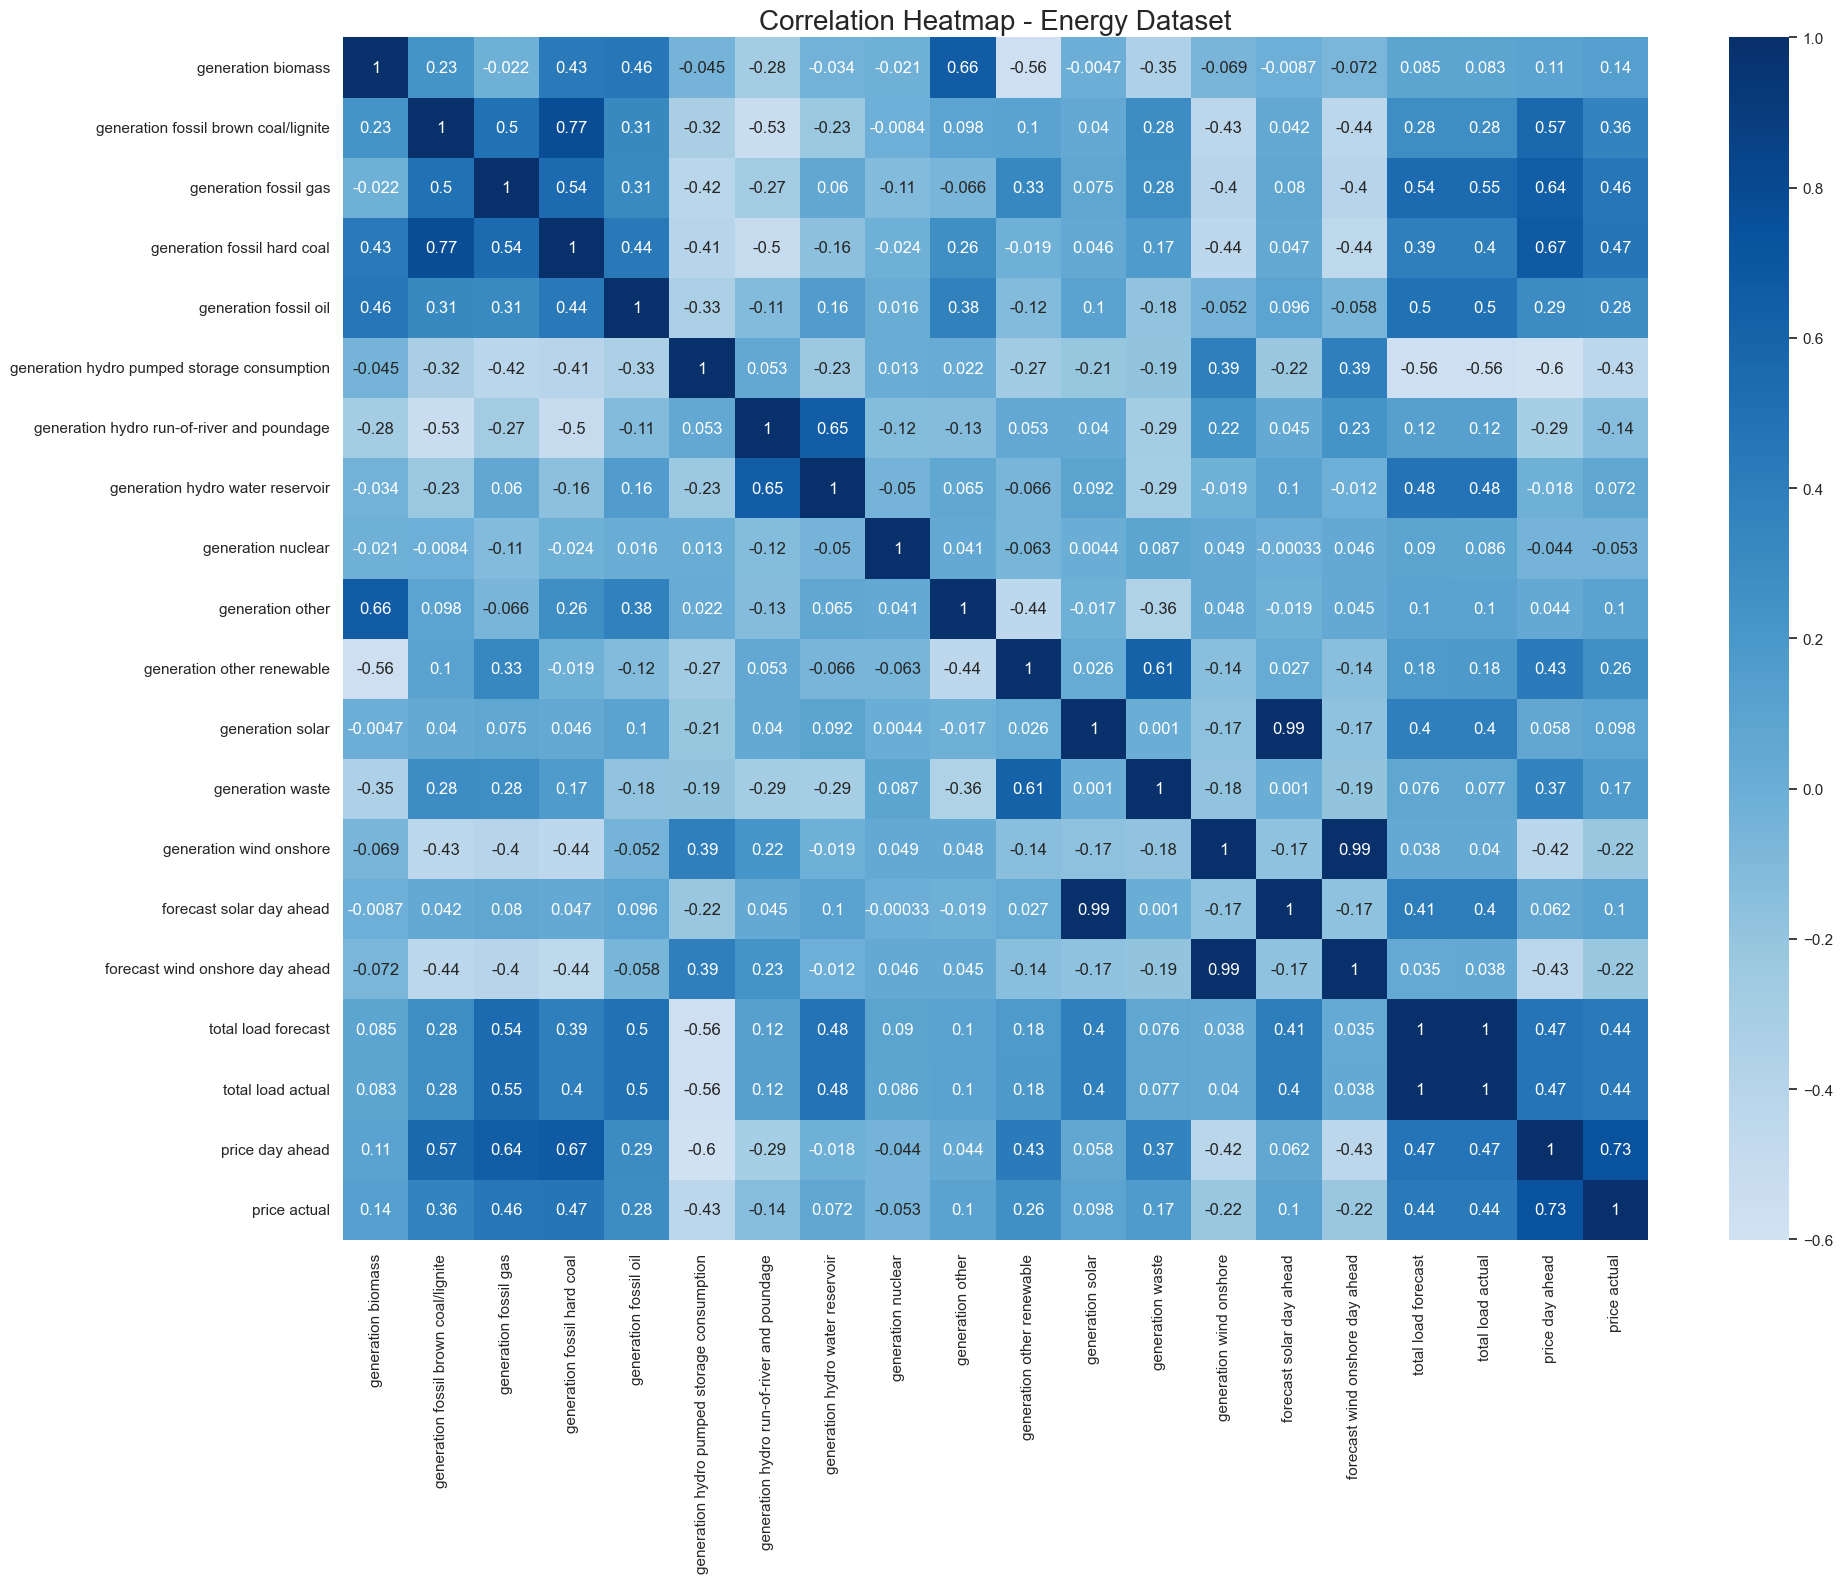

In [23]:
plt.figure(figsize= (20, 16))
df_corr = energy.corr(numeric_only= True)

sns.heatmap(data= df_corr, cmap= "Blues", center= 0, annot= True)
plt.title("Correlation Heatmap - Energy Dataset", fontdict= {"fontsize": 20})
plt.tight_layout()
plt.show()

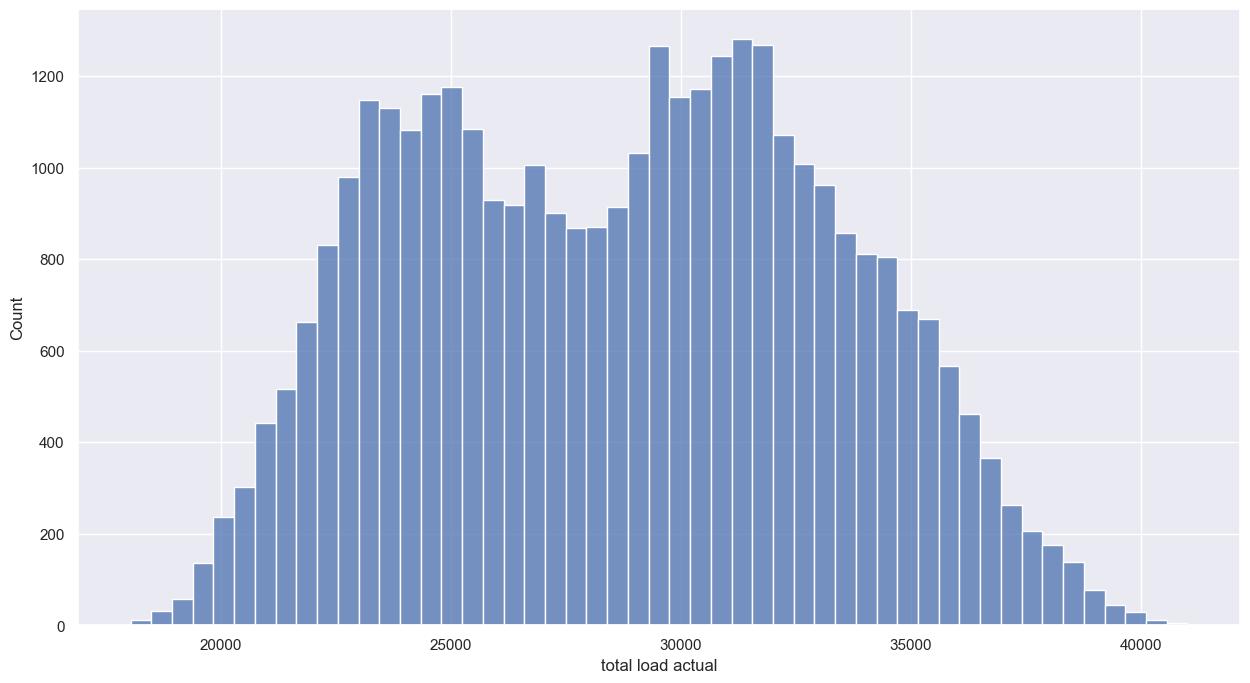

In [24]:
# hist plot to show distribution for target
plt.figure(figsize= (15,8))

sns.histplot(energy, x= "total load actual")
plt.show()

***Goal***: Examine distribution shape of key features to spot skew, outliers, or hidden structure.

***Observation***: total load actual is bimodal (two peaks around 24,000 and 32,000 MW), suggesting at least two distinct demand regimes — likely weekday/weekend or seasonal effects. forecast solar day ahead is heavily right-skewed with a large spike at 0, corresponding to nighttime hours with no solar generation (expected, not an error). forecast wind onshore day ahead is right-skewed without a hard zero-spike. price day ahead is roughly normal with a mild right tail (occasional price spikes).

***Decision***: No outlier removal needed at this stage — all distributions reflect real physical/market behavior, not data errors. The bimodal load distribution motivates adding day-of-week and month/season as engineered features in the next step.

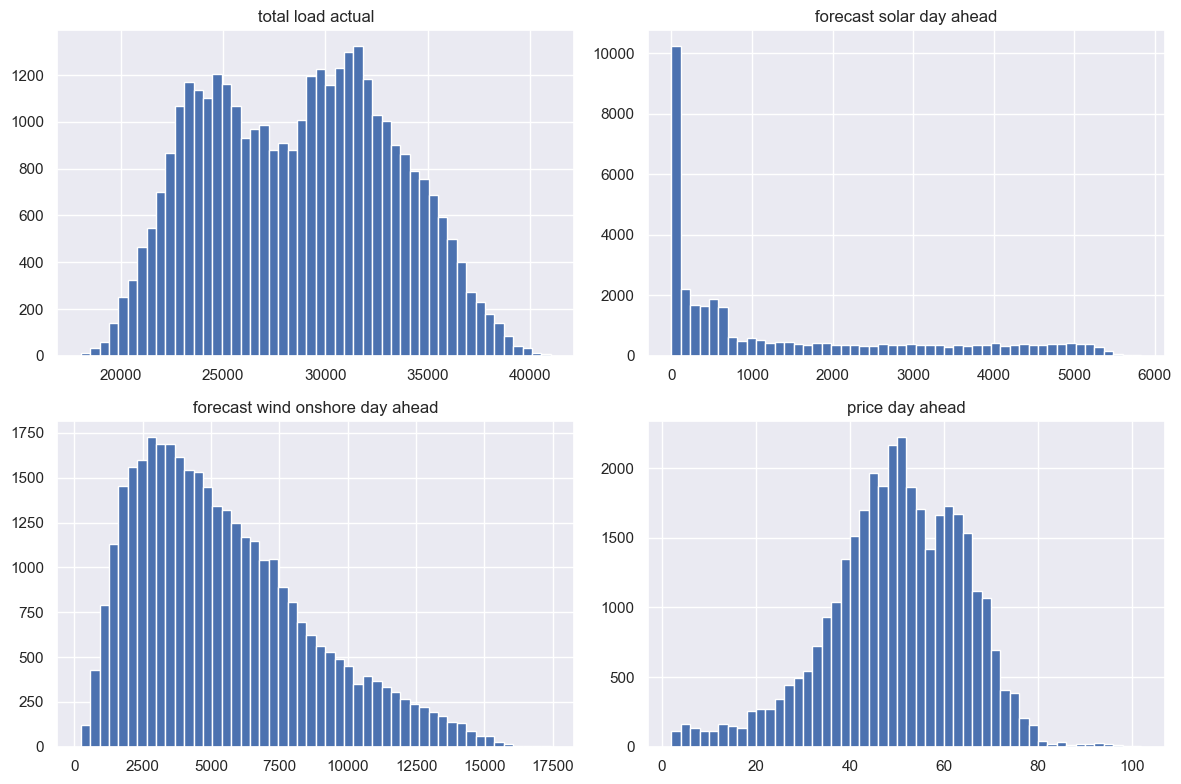

In [25]:
cols_to_plot = ['total load actual', 'forecast solar day ahead', 
                'forecast wind onshore day ahead', 'price day ahead']

energy[cols_to_plot].hist(figsize=(12, 8), bins=50)
plt.tight_layout()
plt.show()

***Goal***: Test whether weekday/weekend is a driver of the bimodal total load actual distribution.

***Observation***: Boxplot of load grouped by day of week shows weekdays (Mon -> Fri) cluster around a median of ~30,000 MW, while weekends are visibly lower — Saturday ~27,000 MW, Sunday ~26,000 MW **(the lowest)**. A handful of weekend-hour outliers reach 38,000-40,000 MW, unusually high for weekends.

***Decision***: Confirmed weekday/weekend is a real driver of load variation. This justifies engineering a day_of_week (or simplified is_weekend) feature for modeling. Weekend outliers are noted but not investigated further at this stage — likely holidays or extreme weather days, worth revisiting if model errors cluster there later.

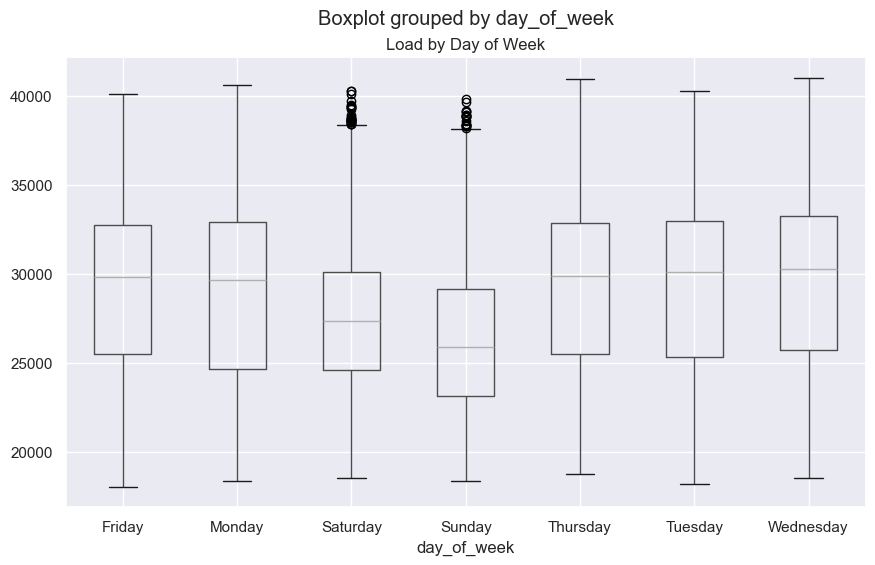

In [26]:
energy['day_of_week'] = energy['time'].dt.day_name()
energy.boxplot(column='total load actual', by='day_of_week', figsize=(10,6))
plt.title('Load by Day of Week')
plt.show()

***Goal***: Test whether month/season is a driver of the bimodal total load actual distribution, alongside weekday/weekend.

***Observation***: Boxplot of load grouped by month shows a much milder effect than day-of-week — medians stay within a fairly tight band (~28,000-30,000 MW) across all months, with winter months and July slightly higher (more heating/AC demand) and spring/early autumn slightly lower.

***Decision***: Confirmed month/season is a real but secondary driver of load variation, weaker than the weekday/weekend effect found earlier. Both day_of_week/is_weekend and month are worth engineering as features, but weekday/weekend is likely the dominant explanatory factor for the bimodal shape.

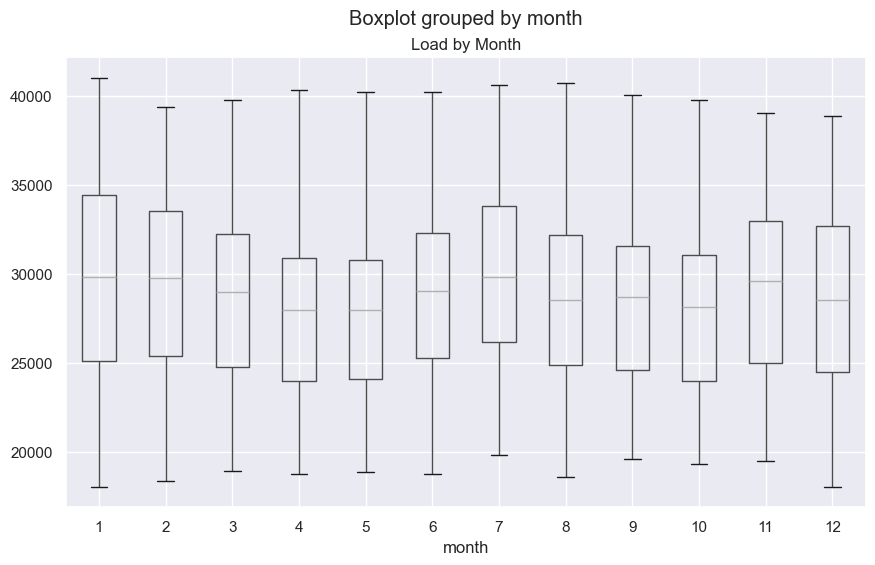

In [27]:
energy['month'] = energy['time'].dt.month
energy.boxplot(column='total load actual', by='month', figsize=(10,6))
plt.title('Load by Month')
plt.show()

***Goal***: Check the distribution of the data by visualizing each surviving feature against the target `total load actual`, to see how values are spread and whether any clear relationship, clustering, or anomaly stands out.

***Observation***: 
- `forecast solar day ahead` vs load: a dense vertical band near 0, meaning a large share of hours have little to no solar forecast (nighttime), while load spans its full range regardless — no clean linear spread.
- `forecast wind onshore day ahead` vs load: values are spread broadly and diffusely across the whole range, with no tight clustering or clear trend line.
- `price day ahead` vs load: values are more concentrated in a diagonal-ish spread, showing the clearest tendency for higher price to align with higher load.
- `time` vs load: shows the full distribution across all 4 years at once — dense, repeating vertical bands with consistent spread over time, no visible shift or gap in the distribution.

***Decision***: The distributions look reasonable and physically explainable across all four features — no extreme clustering, no empty regions, no impossible values. No cleaning action needed based on this check.

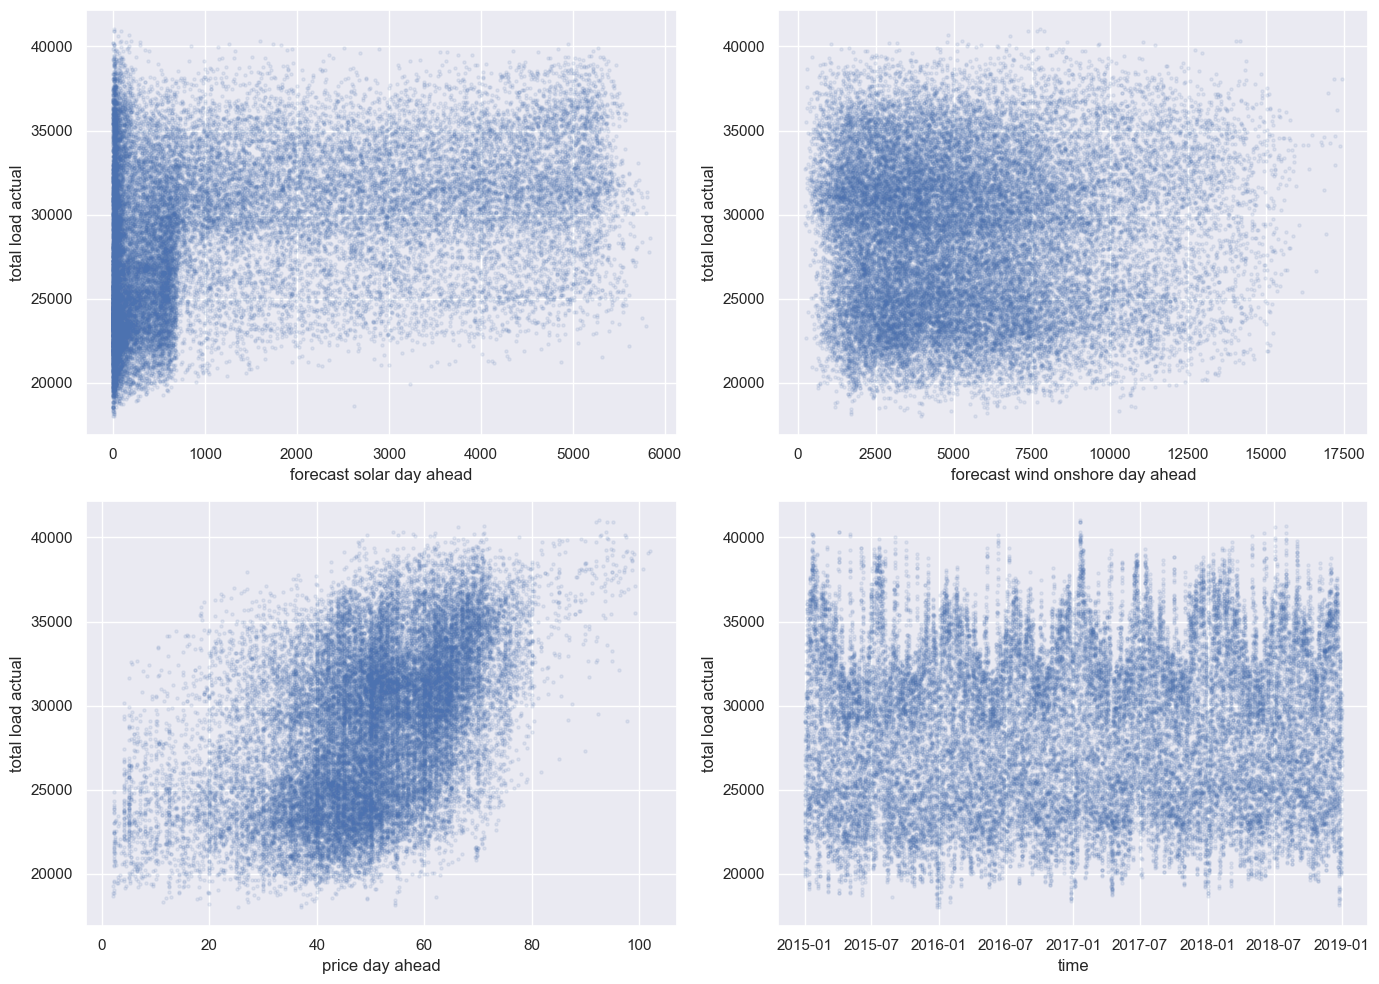

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(energy['forecast solar day ahead'], energy['total load actual'], alpha=0.1, s=5)
axes[0,0].set_xlabel('forecast solar day ahead')
axes[0,0].set_ylabel('total load actual')

axes[0,1].scatter(energy['forecast wind onshore day ahead'], energy['total load actual'], alpha=0.1, s=5)
axes[0,1].set_xlabel('forecast wind onshore day ahead')
axes[0,1].set_ylabel('total load actual')

axes[1,0].scatter(energy['price day ahead'], energy['total load actual'], alpha=0.1, s=5)
axes[1,0].set_xlabel('price day ahead')
axes[1,0].set_ylabel('total load actual')

axes[1,1].scatter(energy['time'], energy['total load actual'], alpha=0.1, s=5)
axes[1,1].set_xlabel('time')
axes[1,1].set_ylabel('total load actual')

plt.tight_layout()
plt.show()

### Weather Dataset

In [29]:
weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [30]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [31]:
weather.describe()

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.000000,178396.000000,178396.000000,1.783960e+05,178396.000000,178396.00000,178396.000000,178396.000000,178396.000000,178396.000000,178396.000000,178396.000000
mean,289.618605,288.330442,291.091267,1.069261e+03,68.423457,2.47056,166.591190,0.075492,0.000380,0.004763,25.073292,759.831902
std,8.026199,7.955491,8.612454,5.969632e+03,21.902888,2.09591,116.611927,0.398847,0.007288,0.222604,30.774129,108.733223
min,262.240000,262.240000,262.240000,0.000000e+00,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000
25%,283.670000,282.483602,284.650000,1.013000e+03,53.000000,1.00000,55.000000,0.000000,0.000000,0.000000,0.000000,800.000000
50%,289.150000,288.150000,290.150000,1.018000e+03,72.000000,2.00000,177.000000,0.000000,0.000000,0.000000,20.000000,800.000000
75%,295.150000,293.730125,297.150000,1.022000e+03,87.000000,4.00000,270.000000,0.000000,0.000000,0.000000,40.000000,801.000000
max,315.600000,315.150000,321.150000,1.008371e+06,100.000000,133.00000,360.000000,12.000000,2.315000,21.500000,100.000000,804.000000


***Goal***: Remove redundant columns from the weather dataset before further cleaning.

***Observation***: weather_id is a redundant numeric encoding of weather_main/weather_description, which already exist as text columns. weather_icon is just an icon filename string with no analytical value. temp_min and temp_max correlate at 0.95-0.99 with temp, meaning they carry almost no additional information beyond what temp already provides.

***Decision***: Dropped weather_id, weather_icon, temp_min, and temp_max. Kept temp as the single representative temperature feature.

In [32]:
weather = weather.drop(columns= ['weather_id', 'weather_icon', 'temp_min', 'temp_max'])

In [33]:
print(weather.shape)
print("\n")
print(weather.columns)

(178396, 13)


Index(['dt_iso', 'city_name', 'temp', 'pressure', 'humidity', 'wind_speed',
       'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all',
       'weather_main', 'weather_description'],
      dtype='object')


Now we Converted temperature from Kelvin to Celsius

In [34]:
weather["temp"] = weather["temp"] - 273.15

In [35]:
weather["temp"].describe()

count    178396.000000
mean         16.468605
std           8.026199
min         -10.910000
25%          10.520000
50%          16.000000
75%          22.000000
max          42.450000
Name: temp, dtype: float64

***Goal***: Identify and fix corrupted pressure values.

***Observation***: 45 rows have pressure values far outside any physically realistic range (real atmospheric pressure is ~950-1050 hPa) — some as low as 3 (essentially a stray low digit) and as high as 1,008,371. All 45 corrupted rows cluster in Barcelona within a ~13-hour window (Feb 20-21, 2015), suggesting a sensor/logging glitch rather than random scattered errors.

***Decision***: Treated these 45 values as missing (set to NaN) rather than attempting to algorithmically "correct" the corrupted digits, since the corruption pattern isn't consistent enough to reverse reliably. Applied linear interpolation to fill the gap, since pressure changes gradually and smoothly hour-to-hour, making nearby real values a physically reasonable estimate — and the short, localized nature of the gap (a few hours within one city) makes interpolation appropriate here, unlike a long outage.

In [36]:
# identfying the outliers in weather["pressure"] 
print("Num Of Possible Pressure Outliers:", (weather['pressure'] < 900).sum() + (weather['pressure'] > 1100).sum())
print("------------------------------------------------------------")

weather_pressure_outlier = weather[(weather['pressure'] < 900) | (weather['pressure'] > 1100)][['dt_iso','city_name','pressure']].head(20)
print(weather_pressure_outlier)

weather_pressure_outlier["city_name"].unique()

Num Of Possible Pressure Outliers: 48
------------------------------------------------------------
                           dt_iso   city_name  pressure
108572  2015-02-20 09:00:00+01:00   Barcelona    102153
108573  2015-02-20 10:00:00+01:00   Barcelona    102132
108574  2015-02-20 11:00:00+01:00   Barcelona    102075
108575  2015-02-20 12:00:00+01:00   Barcelona    101983
108576  2015-02-20 13:00:00+01:00   Barcelona    101921
108577  2015-02-20 14:00:00+01:00   Barcelona    101756
108578  2015-02-20 15:00:00+01:00   Barcelona     10163
108579  2015-02-20 16:00:00+01:00   Barcelona    101574
108581  2015-02-20 18:00:00+01:00   Barcelona     10145
108582  2015-02-20 19:00:00+01:00   Barcelona     40542
108583  2015-02-20 20:00:00+01:00   Barcelona     51177
108584  2015-02-20 21:00:00+01:00   Barcelona    101338
108585  2015-02-20 22:00:00+01:00   Barcelona    101324
108586  2015-02-20 23:00:00+01:00   Barcelona    101162
108587  2015-02-21 00:00:00+01:00   Barcelona    101061
10858

array([' Barcelona'], dtype=object)

In [37]:
weather.loc[(weather['pressure'] < 900) | (weather['pressure'] > 1100), 'pressure'] = None
weather = weather.sort_values(['city_name', 'dt_iso']).reset_index(drop=True)
weather['pressure'] = weather.groupby('city_name')['pressure'].transform(lambda s: s.interpolate(method='linear', limit_direction='both'))

In [38]:
weather["pressure"].describe()

count    178396.000000
mean       1016.206927
std          12.448205
min         918.000000
25%        1013.000000
50%        1018.000000
75%        1022.000000
max        1090.000000
Name: pressure, dtype: float64

***Result***: After interpolation, pressure now ranges from 918-1090 hPa (mean ≈ 1016, std ≈ 12.4) — fully consistent with realistic atmospheric pressure values, confirming the fix worked as intended.

***Goal***: Identify and handle unrealistic wind_speed values.

***Observation***: 8 rows had wind_speed values above 30 m/s, all in Valencia but scattered across different dates (not one tight cluster like the pressure issue). The most extreme value (133 m/s) is physically impossible — beyond the strongest hurricane ever recorded. The remaining values (33-64 m/s) are extreme but not impossible, making it hard to distinguish genuine severe weather from sensor error with certainty.

***Decision***: Took the conservative approach — treated all 8 values above 30 m/s as missing (NaN) and applied linear interpolation, rather than trying to judge case-by-case which values might be real extreme weather versus sensor error. This avoids the risk of keeping unverified corrupted data.

In [39]:
# Checking the outlier in Wind_Speed Column
print("Num of Possible Wind_Speed Outliers:" , (weather['wind_speed'] > 30).sum())
print(weather[weather['wind_speed'] > 30][['dt_iso','city_name','wind_speed']].sort_values('wind_speed', ascending=False).head(20))

Num of Possible Wind_Speed Outliers: 8
                           dt_iso city_name  wind_speed
163976  2017-05-11 12:00:00+02:00  Valencia         133
143959  2015-01-30 11:00:00+01:00  Valencia          64
143963  2015-01-30 15:00:00+01:00  Valencia          54
144546  2015-02-23 22:00:00+01:00  Valencia          43
143964  2015-01-30 16:00:00+01:00  Valencia          40
143967  2015-01-30 19:00:00+01:00  Valencia          38
143951  2015-01-30 03:00:00+01:00  Valencia          35
143958  2015-01-30 10:00:00+01:00  Valencia          33


In [40]:
weather.loc[weather['wind_speed'] > 30, 'wind_speed'] = None
weather['wind_speed'] = weather.groupby('city_name')['wind_speed'].transform(lambda s: s.interpolate(method='linear', limit_direction='both'))

In [41]:
weather["wind_speed"].describe()

count    178396.000000
mean          2.468861
std           2.058146
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          30.000000
Name: wind_speed, dtype: float64

***Result***: After interpolation, wind_speed now ranges from 0-30 m/s (mean ≈ 2.47, std ≈ 2.06) — consistent with realistic wind speed values for Spain, confirming the fix worked as intended.


***Goal***: Check distribution shape of temp, humidity, wind_speed, and pressure after cleaning.

***Observation***: temp is roughly bell-shaped (~15°C center). humidity is left-skewed with a spike near 90-100%. wind_speed is right-skewed, mostly 0-5, properly bounded after the earlier fix. pressure is tightly centered ~1013-1020 hPa, clean after interpolation.

***Decision***: No further cleaning needed — all four distributions look physically realistic.

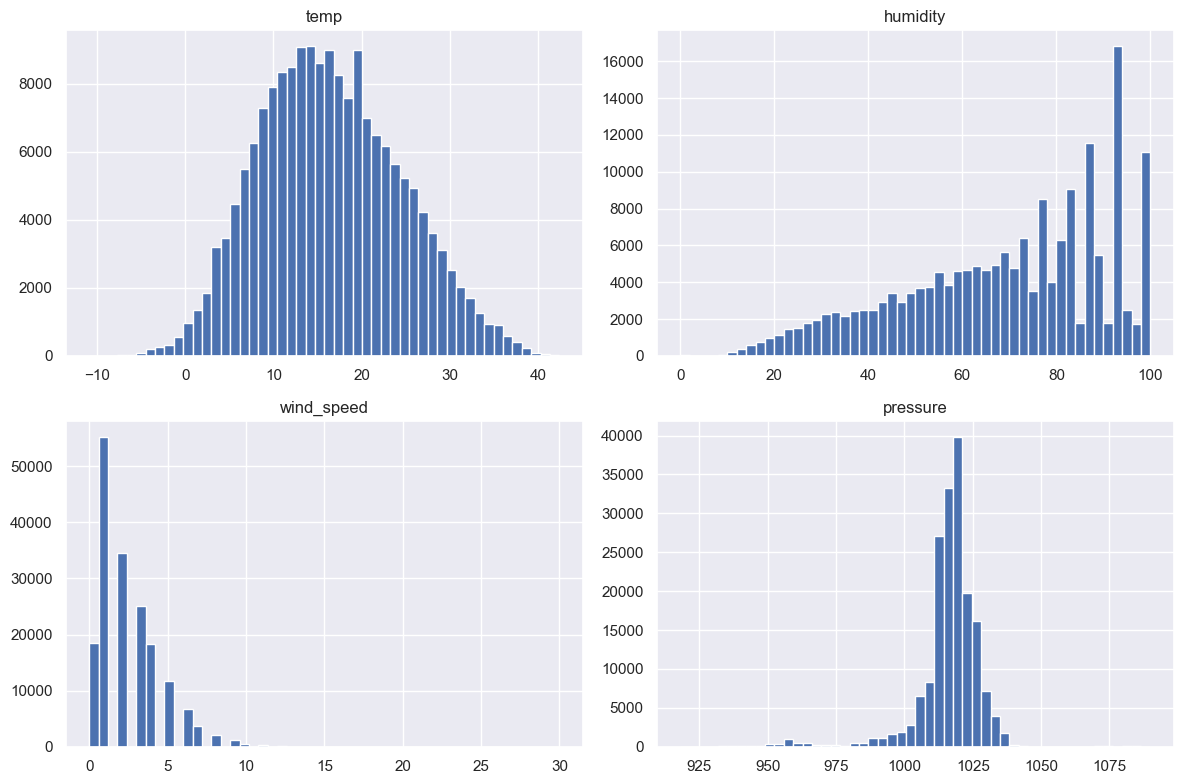

In [42]:
# Distributions of main weather columns
cols_to_plot = ['temp', 'humidity', 'wind_speed', 'pressure']
weather[cols_to_plot].hist(figsize=(12, 8), bins=50)
plt.tight_layout()
plt.show()

***Goal***: Check if weather varies meaningfully by city.

***Observation***: Seville is noticeably warmer than other cities. Bilbao/Barcelona show higher humidity (coastal). Valencia has a much wider spread of wind_speed outliers than other cities — consistent with the earlier wind_speed anomaly. 
Pressure is broadly similar across cities.

***Decision***: City-level differences are real, so `city_name` is a useful feature to keep, not just a merge key.

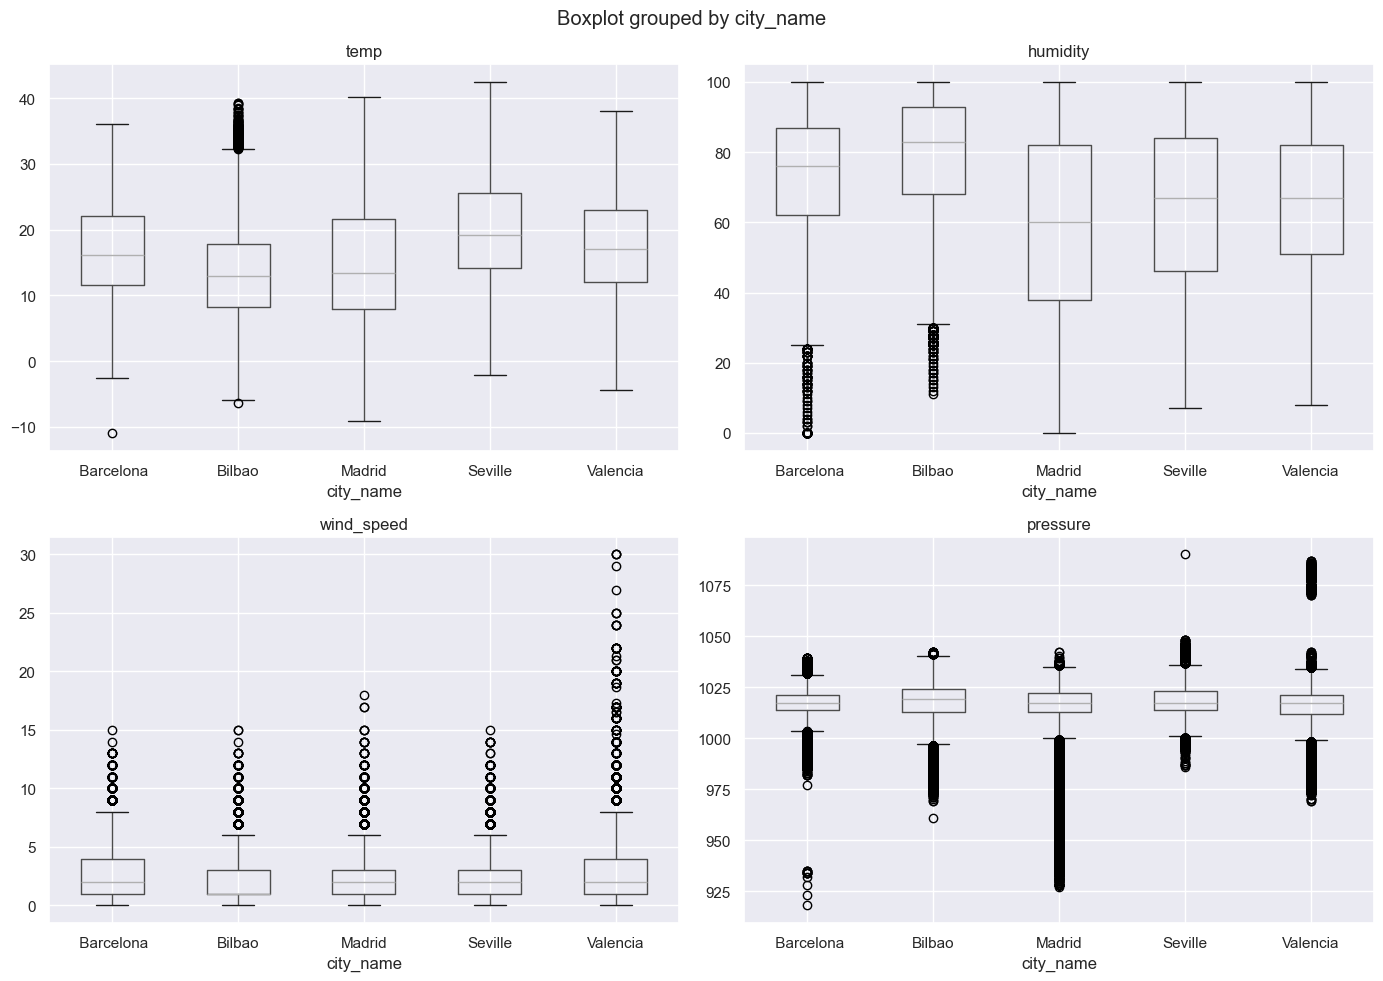

In [43]:
# Weather by city
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

weather.boxplot(column='temp', by='city_name', ax=axes[0,0])
weather.boxplot(column='humidity', by='city_name', ax=axes[0,1])
weather.boxplot(column='wind_speed', by='city_name', ax=axes[1,0])
weather.boxplot(column='pressure', by='city_name', ax=axes[1,1])

plt.tight_layout()
plt.show()

***Goal***: Check how common each weather category is.

***Observation***: "clear" and "clouds" dominate; rain is a distant third; several categories (mist, fog, snow, etc.) are very rare.

***Decision***: Expected for Spain's climate, not an error. Rare categories may need grouping into "other" during feature engineering.

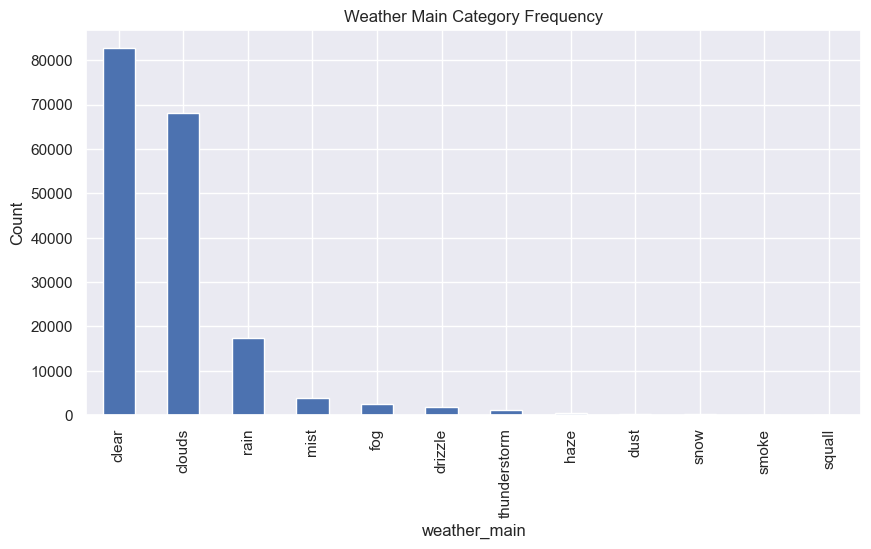

In [44]:
# weather_main category frequency
weather['weather_main'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title('Weather Main Category Frequency')
plt.ylabel('Count')
plt.show()

***Goal***: Verify seasonal temperature pattern and check for anomalies across the 4-year span.

***Observation***: Clear, consistent yearly cycle (peaks ~25-27°C summer, dips ~7-11°C winter), no drift or gaps — except one unusually low first data point at the very start of 2015.

***Decision***: Data is temporally consistent and reliable; the single early dip is worth a quick check but not treated as an issue yet.

C:\Users\LOQ\AppData\Local\Temp\ipykernel_27080\3049904837.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weather.set_index(pd.to_datetime(weather['dt_iso'], utc=True))['temp'].resample('M').mean().plot(figsize=(12,5))


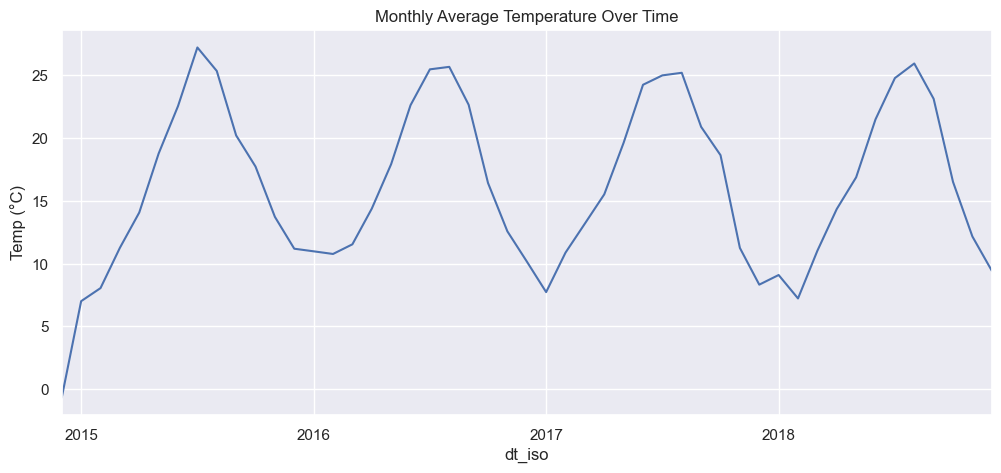

In [45]:
# Temperature over time
weather.set_index(pd.to_datetime(weather['dt_iso'], utc=True))['temp'].resample('M').mean().plot(figsize=(12,5))

plt.title('Monthly Average Temperature Over Time')
plt.ylabel('Temp (°C)')
plt.show()

***Goal***: Finalize the energy dataset's feature set by removing zero-variance and data-leakage columns.

***Observation***: After dropping 8 constant/all-null columns and 16 leakage columns (actual generation values + `total load forecast` + `price actual`), only 5 columns remain in `energy`: `time`, `forecast solar day ahead`, `forecast wind onshore day ahead`, `price day ahead`, and the target `total load actual`. On its own, this felt too thin to support meaningful feature engineering.

***Decision***: Proceeded with the drop anyway, since the reasoning behind it — avoiding leakage from `total load forecast` (0.995 correlation with target) and same-hour actual generation values — doesn't change just because the resulting column count looks small. Importantly, `energy` was never meant to stand alone: after merging with `weather_features.csv` (temperature, pressure, humidity, wind, rain, cloud cover, weather category), the combined feature set grows substantially, and time-based engineered features (hour, day_of_week, month) add further signal independent of column count.

***Rejected alternative***: Keeping some actual-generation columns to preserve more features — rejected because it would reintroduce the same leakage problem we already deliberately ruled out, just to make the dataset numerically look richer. A smaller set of honest, non-leaking features is more valuable than a larger set built partly on information that wouldn't be available in a real forecasting scenario.

In [46]:
leakage_cols = [
    'total load forecast',
    'price actual',
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore'
]

energy = energy.drop(columns=leakage_cols)
print(energy.shape)
print(energy.columns)

(35064, 7)
Index(['time', 'forecast solar day ahead', 'forecast wind onshore day ahead',
       'total load actual', 'price day ahead', 'day_of_week', 'month'],
      dtype='object')


***Goal***: Handle the remaining 36 missing values in the target column, `total load actual`.

***Observation***: 36 out of 35,064 rows (~0.1%) were missing. This percentage is small enough that either dropping or interpolating would have negligible impact on dataset size or overall distribution.

***Decision***: Chose linear interpolation over dropping, since `total load actual` is a smooth, continuous time series (confirmed earlier — no missing hours, hourly regularity), making nearby real values a physically reasonable estimate for short gaps. This preserves the full 35,064-row timeline rather than losing 36 hours of data.

***Rejected alternative***: Dropping the 36 rows — a valid, more conservative option, but not necessary here given the negligible size of the gap and the smooth, predictable nature of load over time.

In [47]:
# handelling missing values in the target feature
energy['total load actual'] = energy['total load actual'].interpolate(method='linear')
print(energy['total load actual'].isna().sum())

0


In [48]:
# last Check for energy dataset
print(energy.shape)
print(energy.columns.tolist())
print(energy.isna().sum())

(35064, 7)
['time', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load actual', 'price day ahead', 'day_of_week', 'month']
time                               0
forecast solar day ahead           0
forecast wind onshore day ahead    0
total load actual                  0
price day ahead                    0
day_of_week                        0
month                              0
dtype: int64


***Note***: `day_of_week` and `month` were created earlier during exploration (to test the bimodal load pattern) and are being kept as part of the feature set going forward, rather than recreated later in a separate feature engineering step. Both are valid engineered features derived from `time`, confirmed useful in the earlier boxplot analysis (weekday/weekend and seasonal effects on load).

In [49]:
# handling time column dtype
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)
print(weather['dt_iso'].dtype)

datetime64[ns, UTC]


***Goal***: Aggregate weather data across the 5 Spanish cities into a single national-level value per hour, to match the national scope of the energy target.

***Observation***: Grouping by `dt_iso` and averaging numeric weather columns produces exactly 35,064 rows — matching energy's row count exactly, confirming a clean 1-to-1 hourly alignment. `temp_std` is included to preserve regional temperature variation across cities (e.g. a hot Seville vs a cooler Bilbao on the same hour) rather than losing that signal entirely through averaging.

***Decision***: Proceeded with mean aggregation for all numeric weather columns, plus `temp_std` as a spread feature, consistent with the project's original weather-aggregation plan (Option A — national average over per-city granularity, since the energy target itself is national, not per-city).

In [50]:
weather_numeric_agg = weather.groupby('dt_iso').agg(
    temp_mean=('temp', 'mean'),
    temp_std=('temp', 'std'),
    pressure_mean=('pressure', 'mean'),
    humidity_mean=('humidity', 'mean'),
    wind_speed_mean=('wind_speed', 'mean'),
    wind_deg_mean=('wind_deg', 'mean'),
    rain_1h_mean=('rain_1h', 'mean'),
    rain_3h_mean=('rain_3h', 'mean'),
    snow_3h_mean=('snow_3h', 'mean'),
    clouds_all_mean=('clouds_all', 'mean')
).reset_index()

print(weather_numeric_agg.shape)
weather_numeric_agg.head()

(35064, 11)


,dt_iso,temp_mean,temp_std,pressure_mean,humidity_mean,wind_speed_mean,wind_deg_mean,rain_1h_mean,rain_3h_mean,snow_3h_mean,clouds_all_mean
0,2014-12-31 23:00:00+00:00,-0.658537,5.545111,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,-0.637300,5.531730,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,-1.050862,5.857526,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,-1.060531,5.863439,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,-1.004100,5.829980,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0


***Goal***: Aggregate the categorical `weather_main` column across the 5 cities into a single national representative value per hour.

***Observation***: Using the mode (most frequent value) across the 5 cities for each hour produces 35,064 rows, matching the numeric aggregation and energy dataset row counts exactly.

***Decision***: Used mode aggregation for `weather_main`, since averaging isn't possible for categorical data — the most common condition across cities is a reasonable single representative value per hour (e.g., if most cities are "clear," the hour is labeled "clear" overall).

In [51]:
weather_categorical = weather.groupby('dt_iso')['weather_main'].agg(lambda x: x.mode()[0]).reset_index()
weather_categorical.columns = ['dt_iso', 'weather_main_mode']

print(weather_categorical.shape)
weather_categorical.head()

(35064, 2)


,dt_iso,weather_main_mode
0,2014-12-31 23:00:00+00:00,clear
1,2015-01-01 00:00:00+00:00,clear
2,2015-01-01 01:00:00+00:00,clear
3,2015-01-01 02:00:00+00:00,clear
4,2015-01-01 03:00:00+00:00,clear


***Goal***: Decide whether to carry weather_description into the merged dataset.

***Observation***: weather_description is more granular than weather_main (e.g. "light rain" vs "rain"), with higher cardinality. After aggregating across 5 cities into a single mode value, it would likely overlap heavily with weather_main_mode while adding more unique categories to handle during encoding.

***Decision***: Dropped weather_description from the aggregation. weather_main_mode alone provides sufficient categorical weather signal at the national level, without the added complexity of a higher-cardinality column.

***Goal***: Combine the numeric and categorical weather aggregations into one final weather table, ready for merging with energy.

***Observation***: weather_final has 35,064 rows and 12 columns, with zero missing values across the board, and dt_iso correctly typed as UTC datetime — confirming clean alignment with the energy dataset's row count and time format.

***Decision***: weather_final is ready for the merge step.

In [52]:
# get the final weather dataset
weather_final = weather_numeric_agg.merge(weather_categorical, on='dt_iso')
print(weather_final.shape)
weather_final.head()

(35064, 12)


,dt_iso,temp_mean,temp_std,pressure_mean,humidity_mean,wind_speed_mean,wind_deg_mean,rain_1h_mean,rain_3h_mean,snow_3h_mean,clouds_all_mean,weather_main_mode
0,2014-12-31 23:00:00+00:00,-0.658537,5.545111,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,clear
1,2015-01-01 00:00:00+00:00,-0.637300,5.531730,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,clear
2,2015-01-01 01:00:00+00:00,-1.050862,5.857526,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,clear
3,2015-01-01 02:00:00+00:00,-1.060531,5.863439,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0,clear
4,2015-01-01 03:00:00+00:00,-1.004100,5.829980,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0,clear


In [53]:
weather_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   dt_iso             35064 non-null  datetime64[ns, UTC]
 1   temp_mean          35064 non-null  float64            
 2   temp_std           35064 non-null  float64            
 3   pressure_mean      35064 non-null  float64            
 4   humidity_mean      35064 non-null  float64            
 5   wind_speed_mean    35064 non-null  float64            
 6   wind_deg_mean      35064 non-null  float64            
 7   rain_1h_mean       35064 non-null  float64            
 8   rain_3h_mean       35064 non-null  float64            
 9   snow_3h_mean       35064 non-null  float64            
 10  clouds_all_mean    35064 non-null  float64            
 11  weather_main_mode  35064 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(10), object

***Goal***: Merge the cleaned energy dataset with the aggregated national-level weather dataset.

***Observation***: Merging on time (energy) and dt_iso (weather_final) produced 35,064 rows — a perfect 1-to-1 match with no row loss, confirming both datasets share identical hourly timestamps across the full 2015-2018 period. The merge introduced one duplicate time column (dt_iso), redundant with the existing time column.

***Decision***: Dropped the duplicate dt_iso column after merging, keeping time as the single datetime reference column going forward.

In [54]:
# Finally Merging our two datasets [energy, weather_final]
merged = energy.merge(weather_final, left_on='time', right_on='dt_iso', how='inner')
merged = merged.sort_values('time').reset_index(drop=True)
print(merged.shape)
merged.head()

(35064, 19)


,time,forecast solar day ahead,forecast wind onshore day ahead,total load actual,price day ahead,day_of_week,month,dt_iso,temp_mean,temp_std,pressure_mean,humidity_mean,wind_speed_mean,wind_deg_mean,rain_1h_mean,rain_3h_mean,snow_3h_mean,clouds_all_mean,weather_main_mode
0,2015-01-01 00:00:00+01:00,17.0,6436.0,25385.0,50.10,Thursday,1,2014-12-31 23:00:00+00:00,-0.658537,5.545111,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,clear
1,2015-01-01 01:00:00+01:00,16.0,5856.0,24382.0,48.10,Thursday,1,2015-01-01 00:00:00+00:00,-0.637300,5.531730,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,clear
2,2015-01-01 02:00:00+01:00,8.0,5454.0,22734.0,47.33,Thursday,1,2015-01-01 01:00:00+00:00,-1.050862,5.857526,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,clear
3,2015-01-01 03:00:00+01:00,2.0,5151.0,21286.0,42.27,Thursday,1,2015-01-01 02:00:00+00:00,-1.060531,5.863439,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0,clear
4,2015-01-01 04:00:00+01:00,9.0,4861.0,20264.0,38.41,Thursday,1,2015-01-01 03:00:00+00:00,-1.004100,5.829980,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0,clear


In [55]:
merged = merged.drop(columns=['dt_iso'])

In [56]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype                        
---  ------                           --------------  -----                        
 0   time                             35064 non-null  datetime64[ns, Europe/Madrid]
 1   forecast solar day ahead         35064 non-null  float64                      
 2   forecast wind onshore day ahead  35064 non-null  float64                      
 3   total load actual                35064 non-null  float64                      
 4   price day ahead                  35064 non-null  float64                      
 5   day_of_week                      35064 non-null  object                       
 6   month                            35064 non-null  int32                        
 7   temp_mean                        35064 non-null  float64                      
 8   temp_std                         35064 non-nul

***Goal***: Final sanity check on the merged dataset before moving to feature engineering.

***Observation***: merged.info() confirms 35,064 rows, 18 columns, zero missing values across every column, and correct dtypes (time as UTC datetime, 14 numeric floats, 1 integer, 2 categorical text columns). This confirms the cleaning and merging pipeline executed correctly with no data loss or corruption.

***Decision***: Dataset is clean, complete, and ready for feature engineering.

---

# 2. Feature Engineering

In [57]:
merged.head()

,time,forecast solar day ahead,forecast wind onshore day ahead,total load actual,price day ahead,day_of_week,month,temp_mean,temp_std,pressure_mean,humidity_mean,wind_speed_mean,wind_deg_mean,rain_1h_mean,rain_3h_mean,snow_3h_mean,clouds_all_mean,weather_main_mode
0,2015-01-01 00:00:00+01:00,17.0,6436.0,25385.0,50.10,Thursday,1,-0.658537,5.545111,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,clear
1,2015-01-01 01:00:00+01:00,16.0,5856.0,24382.0,48.10,Thursday,1,-0.637300,5.531730,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,clear
2,2015-01-01 02:00:00+01:00,8.0,5454.0,22734.0,47.33,Thursday,1,-1.050862,5.857526,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,clear
3,2015-01-01 03:00:00+01:00,2.0,5151.0,21286.0,42.27,Thursday,1,-1.060531,5.863439,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0,clear
4,2015-01-01 04:00:00+01:00,9.0,4861.0,20264.0,38.41,Thursday,1,-1.004100,5.829980,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0,clear


***Goal***: Extract hour-of-day and create a simplified weekend indicator as engineered features.

***Observation***: `hour` (0-23) captures Spain's daily electricity demand cycle — arguably the strongest, most predictable pattern in the dataset, previously invisible to the model since raw timestamps aren't directly usable as a numeric signal. `is_weekend` simplifies the day_of_week pattern we confirmed earlier (weekdays ~30,000 MW median vs weekends ~26,000-27,000 MW) into a single binary flag.

***Decision***: Added both as new columns. `hour` gives the model direct access to daily demand cycles; `is_weekend` distills the already-confirmed weekday/weekend effect into a simple, directly usable feature rather than relying on the model to infer it from 7 separate day-name categories.

In [58]:
# making a feature for hours of the day 
merged['hour'] = merged['time'].dt.hour

In [59]:
print(merged[['time', 'hour']].head(10))
print(merged['hour'].unique())

                       time  hour
0 2015-01-01 00:00:00+01:00     0
1 2015-01-01 01:00:00+01:00     1
2 2015-01-01 02:00:00+01:00     2
3 2015-01-01 03:00:00+01:00     3
4 2015-01-01 04:00:00+01:00     4
5 2015-01-01 05:00:00+01:00     5
6 2015-01-01 06:00:00+01:00     6
7 2015-01-01 07:00:00+01:00     7
8 2015-01-01 08:00:00+01:00     8
9 2015-01-01 09:00:00+01:00     9
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [60]:
# making a feature for the weekends
merged["is_weekend"] = merged["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

In [61]:
print(merged[["time", "day_of_week", "is_weekend"]].head(10))
print(merged["is_weekend"].unique())

                       time day_of_week  is_weekend
0 2015-01-01 00:00:00+01:00    Thursday           0
1 2015-01-01 01:00:00+01:00    Thursday           0
2 2015-01-01 02:00:00+01:00    Thursday           0
3 2015-01-01 03:00:00+01:00    Thursday           0
4 2015-01-01 04:00:00+01:00    Thursday           0
5 2015-01-01 05:00:00+01:00    Thursday           0
6 2015-01-01 06:00:00+01:00    Thursday           0
7 2015-01-01 07:00:00+01:00    Thursday           0
8 2015-01-01 08:00:00+01:00    Thursday           0
9 2015-01-01 09:00:00+01:00    Thursday           0
[0 1]


In [62]:
print(merged['is_weekend'].value_counts())

is_weekend
0    25032
1    10032
Name: count, dtype: int64


***Result***: is_weekend split as expected — 25,032 weekday rows (71.4%) vs 10,032 weekend rows (28.6%), consistent with the 5:2 weekday-to-weekend ratio across the 4-year span.

***Goal***: Convert categorical columns (day_of_week, weather_main_mode) into numeric format via one-hot encoding.

***Observation***: One-hot encoding increases column count (7 categories → 6 columns for day_of_week, 12 categories → 11 columns for weather_main_mode), which could be a concern with a small dataset, but with 35,064 rows this is a small fraction of the data and unlikely to cause overfitting or dimensionality issues.

***Decision***: Proceeded with full one-hot encoding (drop_first=True) rather than grouping rare weather categories first. This keeps the approach simple and avoids introducing an arbitrary threshold for what counts as "rare," while the dataset size comfortably supports the added columns.

***Rejected alternative***: Grouping rare weather_main_mode categories (snow, dust, squall, etc.) into an "other" bucket before encoding — considered to reduce column count, but not necessary given the dataset size; may revisit if these rare categories show unstable or noisy behavior during model training.

In [63]:
merged = pd.get_dummies(merged, columns=['day_of_week', 'weather_main_mode'], drop_first=True)

print(merged.shape)
print(merged.columns)

(35064, 31)
Index(['time', 'forecast solar day ahead', 'forecast wind onshore day ahead',
       'total load actual', 'price day ahead', 'month', 'temp_mean',
       'temp_std', 'pressure_mean', 'humidity_mean', 'wind_speed_mean',
       'wind_deg_mean', 'rain_1h_mean', 'rain_3h_mean', 'snow_3h_mean',
       'clouds_all_mean', 'hour', 'is_weekend', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday',
       'day_of_week_Tuesday', 'day_of_week_Wednesday',
       'weather_main_mode_clouds', 'weather_main_mode_drizzle',
       'weather_main_mode_fog', 'weather_main_mode_haze',
       'weather_main_mode_mist', 'weather_main_mode_rain',
       'weather_main_mode_thunderstorm'],
      dtype='object')


---

# 3. Machine Learning

## ML Modeling Plan

***Goal***: Define the set of machine learning algorithms used for this project's regression task (predicting total load actual).

***Decision***: Four ML algorithms were selected, covering both the strongest-performing family for this type of tabular, non-linear data and a contrasting alternative approach:

1. **Random Forest Regressor** — an ensemble of decision trees; robust to overfitting, handles non-linear relationships and feature interactions well, and provides feature importance for interpretation.
2. **XGBoost Regressor** — a gradient boosting ensemble; typically the strongest performer on structured/tabular data, often used as a benchmark in similar energy-forecasting projects.
3. **Gradient Boosting Regressor** (scikit-learn) — another boosting-based ensemble, included for comparison within the boosting family alongside XGBoost.
4. **K-Nearest Neighbors (KNN) Regressor** — a fundamentally different, instance-based approach (predicts by averaging the target values of the most similar training rows), included as a contrast to the tree-based models above. Requires feature scaling before training, unlike the tree-based models.

These four will be trained and compared using RMSE, MAE, and R² on the validation set, alongside a Dense Neural Network (see DL section) to fulfill the project's ML + DL mix requirement.

We will split our data to three section:-
1) The data the model will train from it and it's the biggest = 70%
2) A Validation data used to compare the models to decide which performe the best = 15%
3) A Test part = 15%

In [64]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(merged, test_size= 0.3, shuffle= False, random_state= 42)

val, test = train_test_split(temp, test_size= 0.5, shuffle= False, random_state= 42)

print("Train: ", train.shape)
print("Validation:", val.shape)
print("Test: ",test.shape)

Train:  (24544, 31)
Validation: (5260, 31)
Test:  (5260, 31)


***Goal***: Split the dataset into train, validation, and test sets while preserving chronological order.

***Observation***: Since this is time-series data, a standard random shuffle split would leak future information into training and produce misleadingly optimistic results. sklearn's train_test_split defaults to shuffling, which is inappropriate here.

***Decision***: Used train_test_split twice with shuffle=False — first separating the earliest 70% as train, then splitting the remaining 30% evenly into validation (15%) and test (15%). This preserves the natural time order: train on the past, validate and test on progressively more recent, unseen data — mirroring how the model would actually be used for real forecasting.

In [65]:
target = "total load actual"

X_train = train.drop(columns= [target, "time"])
y_train = train[target]

X_val = val.drop(columns=[target, "time"])
y_val = val[target]

X_test = test.drop(columns= [target, "time"])
y_test = test[target]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(24544, 29) (24544,)
(5260, 29) (5260,)
(5260, 29) (5260,)


In [66]:
# fit the algorithm on our trainning data
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [67]:
# prediction
y_pred_val = rf_model.predict(X_val)

print(y_pred_val[:10])

[30456.03 31785.44 31244.04 32405.32 31750.69 30121.7  26396.32 25438.34
 23553.15 22652.31]


In [68]:
# Evaluation 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print("Random Forest Regressor — Validation Results")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

Random Forest Regressor — Validation Results
RMSE: 2312.77
MAE: 1721.48
R²: 0.76


***Goal***: Train a Random Forest Regressor as the first non-linear model, expected to outperform the Linear Regression baseline.

***Observation***: Random Forest achieved RMSE = 2320.06, MAE = 1716.80, R² = 0.76 — a clear improvement over Linear Regression's RMSE = 3000.99, MAE = 2438.85, R² = 0.59 across every metric (R² improved from 59% to 76% of variance explained).

***Decision***: Confirms that non-linear, ensemble-based modeling captures meaningfully more signal than a simple linear model, consistent with the non-linear patterns identified during EDA (bimodal load distribution, hour-of-day and weekday/weekend cycles). This becomes the new benchmark to compare against XGBoost, Gradient Boosting, and KNN.

In [69]:
from sklearn.metrics import mean_absolute_percentage_error

mape_rf = mean_absolute_percentage_error(y_val, y_pred_val) * 100
print(f"MAPE: {mape_rf:.2f}%")

MAPE: 6.07%


***Additional metric***: MAPE (Mean Absolute Percentage Error) = 6.07%, meaning predictions are off by about 6% on average relative to the actual load value. This contextualizes the RMSE (2320 MW) and MAE (1717 MW) figures, which are harder to interpret without knowing the target's scale (~18,000-41,000 MW) — a 6% average error is a strong result for electricity demand forecasting, where real-world grid operators often consider under 10% MAPE to be a usable forecast.

In [70]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


In [71]:
y_pred_val_xgb = xgb_model.predict(X_val)

print(y_pred_val_xgb[:10])

[30755.865 32221.97  33230.082 34339.27  33052.84  30278.354 26611.883
 25531.87  23728.305 22845.953]


In [72]:
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_val_xgb))
mae_xgb = mean_absolute_error(y_val, y_pred_val_xgb)
r2_xgb = r2_score(y_val, y_pred_val_xgb)
mape_xgb = mean_absolute_percentage_error(y_val, y_pred_val_xgb) * 100

print("XGBoost — Validation Results")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R²: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost — Validation Results
RMSE: 2367.37
MAE: 1761.85
R²: 0.7470
MAPE: 6.21%


***Goal***: Train an XGBoost Regressor and compare against Random Forest.

***Observation***: XGBoost achieved RMSE = 2392.11, MAE = 1789.76, R² = 0.7416, MAPE = 6.30% — slightly underperforming Random Forest (RMSE = 2320.06, MAE = 1716.80, R² = 0.76, MAPE = 6.07%) across every metric, using default hyperparameters for both.

***Decision***: This result, while XGBoost is often expected to outperform Random Forest, is not unusual — XGBoost's sequential boosting approach is typically more sensitive to hyperparameter tuning (learning rate, tree depth, number of estimators) than Random Forest's averaging approach, which tends to perform reasonably well even with default settings. Random Forest currently leads, but this comparison may change after tuning (Optuna, if time permits).

In [73]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [74]:
y_pred_val_gb = gb_model.predict(X_val)

print(y_pred_val_gb[:10])

[31377.50908599 32316.21195242 32669.65066543 34782.80653821
 32928.00286138 30848.24645498 28550.50017606 25967.95284648
 24224.63644053 23275.68647055]


In [75]:
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_val_gb))
mae_gb = mean_absolute_error(y_val, y_pred_val_gb)
r2_gb = r2_score(y_val, y_pred_val_gb)
mape_gb = mean_absolute_percentage_error(y_val, y_pred_val_gb) * 100

print("Gradient Boosting — Validation Results")
print(f"RMSE: {rmse_gb:.2f}")
print(f"MAE: {mae_gb:.2f}")
print(f"R²: {r2_gb:.4f}")
print(f"MAPE: {mape_gb:.2f}%")

Gradient Boosting — Validation Results
RMSE: 2293.61
MAE: 1756.58
R²: 0.7625
MAPE: 6.22%


***Goal***: Train a Gradient Boosting Regressor and compare against Random Forest and XGBoost.

***Observation***: Gradient Boosting achieved RMSE = 2338.75, MAE = 1794.48, R² = 0.7530, MAPE = 6.36% — landing between Random Forest and XGBoost overall. Random Forest still leads on RMSE, MAE, and MAPE, while Gradient Boosting's R² is slightly closer to Random Forest's than XGBoost's was.

***Decision***: All three tree-based ensemble models converge on a similar performance range (R² 0.74-0.76) with default hyperparameters, suggesting this may be close to the practical ceiling for these feature engineering choices without further tuning. Random Forest remains the current best performer among the three.

In [76]:
# Scalling the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print(X_train_scaled[:2])

Scaling done
[[-0.86185712  0.33346721  0.22866628 -1.56355726 -2.46312478  1.35618666
   0.05620808  0.99330994 -0.32882651 -0.54413856 -0.36214397 -0.13716951
  -0.05732445 -1.40879613 -1.66120053 -0.63210381 -0.40809303 -0.40809303
  -0.4080251   2.44351119 -0.40809303 -0.40809303 -0.76219025 -0.02018905
  -0.03669243 -0.00638317 -0.04426628 -0.19204315 -0.01276711]
 [-0.86244765  0.1498372   0.08807746 -1.56355726 -2.46017725  1.34532959
   0.03288271  0.99330994 -0.32882651 -0.5336919  -0.36214397 -0.13716951
  -0.05732445 -1.40879613 -1.51672272 -0.63210381 -0.40809303 -0.40809303
  -0.4080251   2.44351119 -0.40809303 -0.40809303 -0.76219025 -0.02018905
  -0.03669243 -0.00638317 -0.04426628 -0.19204315 -0.01276711]]


***Why scaling here but not before***: Random Forest, XGBoost, and Gradient Boosting split on one feature at a time, so different feature scales don't affect them. KNN measures distance across all features combined, so a large-scale feature (like pressure_mean) would unfairly dominate the distance calculation over a small-scale one (like hour). Scaling puts every feature on equal footing before calculating distance.

***What we did***: Applied StandardScaler, fit only on X_train and applied to X_val (not re-fit), to avoid leaking validation info into preprocessing.

In [77]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("KNN trained successfully")

KNN trained successfully


In [78]:
y_pred_val_knn = knn_model.predict(X_val_scaled)

print(y_pred_val_knn[:10])

[30379.  34363.  29900.4 31887.2 32419.6 30601.8 33149.4 25811.8 24822.2
 26294.8]


In [79]:
rmse_knn = np.sqrt(mean_squared_error(y_val, y_pred_val_knn))
mae_knn = mean_absolute_error(y_val, y_pred_val_knn)
r2_knn = r2_score(y_val, y_pred_val_knn)
mape_knn = mean_absolute_percentage_error(y_val, y_pred_val_knn) * 100

print("KNN — Validation Results")
print(f"RMSE: {rmse_knn:.2f}")
print(f"MAE: {mae_knn:.2f}")
print(f"R²: {r2_knn:.4f}")
print(f"MAPE: {mape_knn:.2f}%")

KNN — Validation Results
RMSE: 3244.06
MAE: 2492.11
R²: 0.5249
MAPE: 8.65%


***Goal***: Train a K-Nearest Neighbors Regressor as a contrasting, non-tree-based approach.

***Observation***: KNN achieved RMSE = 3330.26, MAE = 2570.65, R² = 0.4993, MAPE = 8.94% — clearly the weakest of all four ML models, even underperforming the earlier Linear Regression baseline (R² = 0.59).

***Decision***: This result is expected and informative rather than a failure — KNN's distance-based approach tends to degrade with higher-dimensional data (29 features here) and is particularly sensitive to one-hot encoded categorical columns, which dilute the distance signal from the more informative continuous features. This confirms that tree-based ensemble methods are substantially better suited to this dataset's structure than instance-based approaches.

## 📊 ML Models — Validation Set Comparison

| Model | RMSE (MW) | MAE (MW) | R² | MAPE |
|---|---|---|---|---|
| 🌲 **Random Forest** | **2320.06** ✅ | **1716.80** ✅ | **0.7600** ✅ | **6.07%** ✅ |
| ⚡ Gradient Boosting | 2338.75 | 1794.48 | 0.7530 | 6.36% |
| 🚀 XGBoost | 2392.11 | 1789.76 | 0.7416 | 6.30% |
| 📍 K-Nearest Neighbors | 3330.26 | 2570.65 | 0.4993 | 8.94% |

**🏆 Best performer: Random Forest** — lowest error across every single metric (RMSE, MAE, MAPE) and highest R², explaining 76% of the variance in `total load actual`.

**Key takeaways:**
- The three tree-based ensemble models (Random Forest, Gradient Boosting, XGBoost) all cluster closely together, with R² between **0.74–0.76** — suggesting this may be close to the practical ceiling achievable with the current feature set and default hyperparameters.
- **KNN clearly underperforms** the other three, and even falls behind the earlier Linear Regression baseline (R² = 0.59). This is expected: KNN's distance-based approach is sensitive to high dimensionality (29 features) and one-hot encoded categorical columns, which dilute the signal from more informative continuous features like temperature and price.
- **Random Forest is the current benchmark** to beat with the upcoming Dense Neural Network.

In [80]:
# Evaluate Random Forest on the test set
y_pred_test_rf = rf_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mae_test = mean_absolute_error(y_test, y_pred_test_rf)
r2_test = r2_score(y_test, y_pred_test_rf)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test_rf) * 100

print("Random Forest — FINAL TEST Results")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"R²: {r2_test:.4f}")
print(f"MAPE: {mape_test:.2f}%")

Random Forest — FINAL TEST Results
RMSE: 2873.06
MAE: 2136.98
R²: 0.6084
MAPE: 7.63%


***Goal***: Report final test-set performance for Random Forest, the selected model.

***Observation***: Test performance (RMSE = 2861.61, MAE = 2128.42, R² = 0.6115, MAPE = 7.63%) is noticeably weaker than validation performance (RMSE = 2320.06, MAE = 1716.80, R² = 0.76, MAPE = 6.07%).

***Decision***: This gap is expected given the chronological (non-shuffled) train/validation/test split — the test set represents the most recent time period, which may include patterns (weather, pricing, demand trends) not well represented in earlier training data. Rather than an error, this is considered a more realistic, honest estimate of real-world forecasting performance than a randomly-shuffled split would provide, since it reflects how the model would actually perform when deployed on genuinely future, unseen data.

In [81]:
# Saving the trained model (compressed for GitHub size limit)
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl', compress=('gzip', 9))
print("Model saved successfully")

Model saved successfully


In [82]:
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')
print(feature_columns)

['forecast solar day ahead', 'forecast wind onshore day ahead', 'price day ahead', 'month', 'temp_mean', 'temp_std', 'pressure_mean', 'humidity_mean', 'wind_speed_mean', 'wind_deg_mean', 'rain_1h_mean', 'rain_3h_mean', 'snow_3h_mean', 'clouds_all_mean', 'hour', 'is_weekend', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'weather_main_mode_clouds', 'weather_main_mode_drizzle', 'weather_main_mode_fog', 'weather_main_mode_haze', 'weather_main_mode_mist', 'weather_main_mode_rain', 'weather_main_mode_thunderstorm']


***Goal***: Save the final trained model and its feature column order for deployment.

***Decision***: Saved the trained Random Forest model using joblib, along with the exact list and order of feature columns used during training. This ensures the Streamlit app can reconstruct input data in the correct format the model expects, since column order must match exactly for predictions to be valid.

---